# Домашняя работа 13

In [1]:
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## Импорт датасета

In [3]:
dataset = load_dataset("emotion")
data = dataset["train"]
label_names = data.features["label"].names

df = pd.DataFrame({
    "text": [item["text"] for item in data],
    "label": [label_names[item["label"]] for item in data]
})

df.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger


In [4]:
# Смотрим размер датасета и распределение по классам.
print("Размер датасета:", len(df))
display(df["label"].value_counts())

label_names = sorted(df["label"].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

display(df.sample(6, random_state=42).reset_index(drop=True))

Размер датасета: 16000


label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

label2id: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
id2label: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}


,text,label,label_id
0,ive made it through a week i just feel beaten down,sadness,4
1,i feel this strategy is worthwhile,joy,2
2,i feel so worthless and weak what does he have to say that s what i want to find out,sadness,4
3,i feel clever nov,joy,2
4,im moved in ive been feeling kind of gloomy,sadness,4
5,i allowed myself to feel the really shitty feelings while i was running because a the endorphins were flowing so it hurt less and b so i...,sadness,4


## Train/Validation/Test split

In [5]:
# Сначала отделяем test (20%), затем из оставшихся данных выделяем validation (25% от остатка),
# что в итоге даёт приблизительно 60/20/20.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"],
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=42,
    stratify=train_df["label_id"],
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nРаспределение классов в train:")
display(train_df["label"].value_counts())

print("Распределение классов в validation:")
display(val_df["label"].value_counts())

print("Распределение классов в test:")
display(test_df["label"].value_counts())

Train: (9600, 3)
Validation: (3200, 3)
Test: (3200, 3)

Распределение классов в train:


label
joy         3217
sadness     2800
anger       1295
fear        1163
love         782
surprise     343
Name: count, dtype: int64

Распределение классов в validation:


label
joy         1073
sadness      933
anger        432
fear         387
love         261
surprise     114
Name: count, dtype: int64

Распределение классов в test:


label
joy         1072
sadness      933
anger        432
fear         387
love         261
surprise     115
Name: count, dtype: int64

In [6]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["text", "label_id"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 3200
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 3200
    })
})

In [7]:
# Посмотрим на несколько примеров.
print("Пример из train:")
display(dataset_dict["train"][:3])

print("Пример из validation:")
display(dataset_dict["validation"][:3])

Пример из train:


{'text': ['i kicked you in the throat and now i feel terrific',
  'i should feel like successful independent woman a la destinys child no',
  'i feel nostalgic for old books which i often reread'],
 'labels': [2, 2, 3]}

Пример из validation:


{'text': ['im sitting on the couch thinking about how miserable i feel from indulging in too much delicious food',
  'i just need to find ways to feel pretty',
  'i didnt even have time to feel jealous i was so busy pinning her pictures and writing down a href http nanashi'],
 'labels': [2, 2, 0]}

Мы классифицируем эмоциональный аспект текста, базовые эмоции человека

In [8]:
# Компактная русскоязычная BERT-подобная модель.
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model checkpoint:", MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: cointegrated/rubert-tiny2


Map: 100%|██████████| 3200/3200 [00:00<00:00, 31999.04 examples/s]


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
})

In [9]:
# Смотрим, как теперь выглядит один пример после токенизации.
example = tokenized_datasets["train"][0]
print("Ключи примера:", example.keys())
print("labels:", example["labels"])
print("input_ids[:20]:", example["input_ids"][:20])
print("attention_mask[:20]:", example["attention_mask"][:20])

print("\nДекодированный текст по input_ids:")
print(tokenizer.decode(example["input_ids"]))

Ключи примера: dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
labels: 2
input_ids[:20]: [2, 76, 17177, 737, 2406, 532, 531, 22726, 19714, 537, 1741, 76, 12235, 2232, 16325, 1267, 3]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Декодированный текст по input_ids:
[CLS] i kicked you in the throat and now i feel terrific [SEP]


In [10]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 17)
token_type_ids: shape=(3, 17)
attention_mask: shape=(3, 17)


In [11]:
# Загружаем модель для классификации.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 9604.74it/s]
BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were n

Model class: BertForSequenceClassification
Number of labels: 6
id2label: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'love', 4: 'sadness', 5: 'surprise'}


## Инференс готовой модели

In [12]:
# Создаём high-level pipeline для классификации текста.
text_clf = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
)

demo_texts = test_df["text"].sample(5, random_state=42).tolist()

pipeline_outputs = text_clf(demo_texts)

pipeline_df = pd.DataFrame(
    {
        "text": demo_texts,
        "predicted_label": [item["label"] for item in pipeline_outputs],
        "score": [item["score"] for item in pipeline_outputs],
    }
)

pipeline_df

,text,predicted_label,score
0,ive told friends and fellow fans i feel like weve all been partaking in a delicious feast these last seasons and now were about to get t...,fear,0.1709
1,i feel like this is something i can do well and its helped me out of tough spots before,fear,0.1712
2,i cough alot more and feel somewhat irritable at times,sadness,0.1740
3,im the type who doesnt use a moisturizer as my skin is too oily so this product is designed to contain a ton of moisturizing ingredients...,surprise,0.1711
4,i feel we would be a far better species,surprise,0.1716


Готовая модель не подходит для задачи, потому что имеет низкую уверенность, нелогичные предсказания и у модели нет разделительной способности

## Fine-tuning для классификации текста

In [13]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [14]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [15]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.041225,0.978730,0.630000,0.349617,0.543011
2,0.834868,0.563851,0.826250,0.731159,0.814454
3,0.166166,0.424445,0.861563,0.811677,0.860060
4,0.216957,0.390889,0.876875,0.838823,0.876316
5,0.339638,0.371725,0.876250,0.831335,0.875410


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.11it/s]
c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.79it/s]
c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.67it/s]
c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().

TrainOutput(global_step=6000, training_loss=0.6370048060727617, metrics={'train_runtime': 783.9392, 'train_samples_per_second': 61.229, 'train_steps_per_second': 7.654, 'total_flos': 31284905024160.0, 'train_loss': 0.6370048060727617, 'epoch': 5.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.7908,1.9266,1.9997e-05,0.0017,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.7880,2.2444,1.9990e-05,0.0033,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.7842,1.8260,1.9983e-05,0.0050,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.7986,1.7599,1.9977e-05,0.0067,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.7867,1.7025,1.9970e-05,0.0083,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.7867,1.8559,1.9963e-05,0.0100,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.7697,1.6222,1.9957e-05,0.0117,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.7487,1.5125,1.9950e-05,0.0133,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.7591,2.2001,1.9943e-05,0.0150,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.7693,1.4794,1.9937e-05,0.0167,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


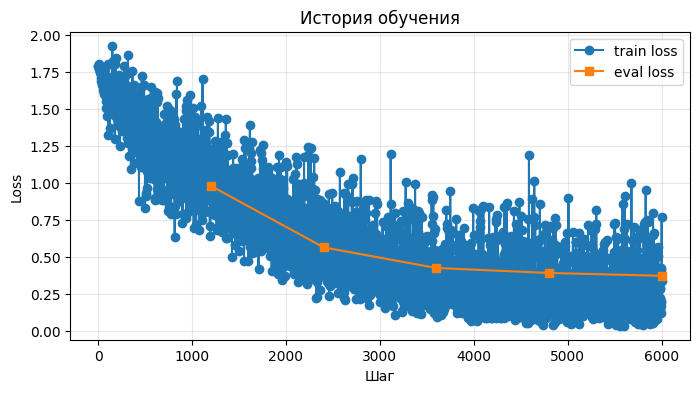

In [16]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [17]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.3907
eval_accuracy: 0.8772
eval_f1_macro: 0.8390
eval_f1_weighted: 0.8766
eval_runtime: 5.2491
eval_samples_per_second: 609.6250
eval_steps_per_second: 76.2030
epoch: 5.0000

Test metrics:
eval_loss: 0.3954
eval_accuracy: 0.8669
eval_f1_macro: 0.8285
eval_f1_weighted: 0.8658
eval_runtime: 4.8134
eval_samples_per_second: 664.8040
eval_steps_per_second: 83.1010
epoch: 5.0000


c:\Users\maxim\OneDrive\Документы\aie_course_rep\aie_course_rep\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification report on test:
              precision    recall  f1-score   support

       anger       0.83      0.84      0.84       432
        fear       0.83      0.85      0.84       387
         joy       0.91      0.89      0.90      1072
        love       0.77      0.65      0.71       261
     sadness       0.89      0.93      0.91       933
    surprise       0.76      0.81      0.78       115

    accuracy                           0.87      3200
   macro avg       0.83      0.83      0.83      3200
weighted avg       0.87      0.87      0.87      3200



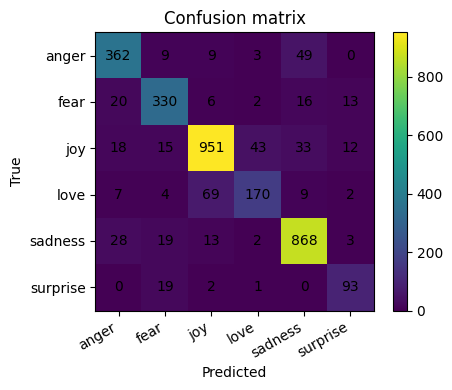

In [22]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Таблица ошибок на тестовой выборке.
test_texts = test_df.reset_index(drop=True)["text"]
error_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if true_id != pred_id:
        error_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        })

errors_df = pd.DataFrame(error_rows)

if len(errors_df) == 0:
    print("На тестовой выборке ошибок не найдено. Это возможно на маленьком учебном датасете.")
else:
    display(errors_df.sort_values(by="confidence", ascending=False).reset_index(drop=True))

,text,true_label,pred_label,confidence
0,i feel safer so i didnt have that horrible panicky feeling like i used to after nightmares in the old place but i couldnt get back to sleep,sadness,joy,0.9879
1,i feel that his apology was sincere i just couldnt help feeling a bit more unhappy about what happened,joy,sadness,0.9878
2,i love this feeling i feel that despite this rain despite the gloomy sky i am feeling good and im feeling fine,sadness,joy,0.9870
3,i still feel very emo but its now a bouncy butterflies in my tummy everythings gonna be ok kinda email rather than a feeling shitty emo so,joy,sadness,0.9858
4,i feel fab if i can get hours sleep in one go but sam doesnt always oblige,joy,sadness,0.9858
...,...,...,...,...
421,i feel like i need to do something to change this vicious cycle of being good and letting cravings drive me to madness and binging,anger,joy,0.3628
422,i imagine how would it feel to hold you nothing perverse just to know you to feel the heat of your breathe moving through me your feet t...,sadness,anger,0.3540
423,im still not feeling these days but cuddling with them almost always makes me feel a little bit better,joy,sadness,0.3342
424,my roommates lack of consideration of me,anger,fear,0.3333


Судя по примерам ошибок, модель часто путает противоположные эмоции, причем в первых ошибках модель очень уверена в своих ответах, а также модели не хватает обучения на нюансах, например сарказм, противоречия, сложные эмоции

## Сохранение артефактов

Сохраним первые 500 примеров предсказаний модели

In [24]:
example_pred_rows = []

for text, true_id, pred_id, prob_vector in zip(test_texts, test_true, test_preds, torch.softmax(torch.tensor(test_logits), dim=-1).numpy()):
    if len(example_pred_rows) <= 500:
        example_pred_rows.append({
            "text": text,
            "true_label": id2label[int(true_id)],
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        })
    else:
        break

example_pred_rows = pd.DataFrame(example_pred_rows)

display(example_pred_rows.head(10))
example_pred_rows.to_csv("artifacts/sample_predictions.csv", index=False)

,text,true_label,pred_label,confidence
0,i feel wronged by certain people and my instinct was to get angry at them and stop speaking to them but two wrongs dont make a right i t...,anger,anger,0.9717
1,i feel so calm with the routine rinse wash with detergent rinse take outside to line dry,joy,joy,0.9810
2,i feel like im not welcomed here i just dont like blend in or something,joy,joy,0.9696
3,i feel totally listless exams have come and gone and now i have a whole five or so months in front of me with no uni and free time,sadness,sadness,0.9469
4,i am feeling confident that i will be able to get to the back door before dinner time,joy,joy,0.9842
5,i feel pretty rotten when jake takes off down the street on his hot rod mongoose and jordan strikes out trying to chase him down like an...,sadness,sadness,0.9788
6,i always feel awkward when im alone in a crowd of peers and feel the need to make friends,sadness,sadness,0.9461
7,when my mums brother passed away after having been involved in a car accident he was bringing me a present as i had passed my form five ...,sadness,sadness,0.6681
8,i also feel that the people in the village friendly and i do not need to be as alert as in manila though as the common sense rule still ...,joy,joy,0.9521
9,i have a feeling of being scared but also knowing that i am in for some really big changes in my mind body and spirit,fear,fear,0.9164
